# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .

Make sure to display outputs for each code cell when submitting.

### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

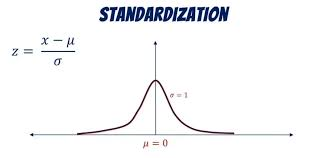


In [37]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load the dataset (semicolon-separated)
df = pd.read_csv('/content/Africa_1997-2020_Jan08.csv', sep=';')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

# DATA HANDLING

# Identify non-numeric columns
non_numeric_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nNon-numeric columns ({len(non_numeric_cols)}): {non_numeric_cols}")

# Create a working copy
df_encoded = df.copy()

# Handle missing values in non-numeric columns with 'Missing' label, then encode
label_encoders = {}
for col in non_numeric_cols:
    le = LabelEncoder()
    df_encoded[col] = df_encoded[col].fillna('Missing')
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded '{col}' — {le.classes_.shape[0]} unique values")

# Handle missing values in numeric columns with mean imputation
numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    missing_count = df_encoded[col].isnull().sum()
    if missing_count > 0:
        mean_val = df_encoded[col].mean()
        df_encoded[col].fillna(mean_val, inplace=True)
        print(f"Imputed '{col}' with mean ({mean_val:.2f}) — {missing_count} missing values")

print(f"\nFinal dataset shape: {df_encoded.shape}")
print(f"Remaining missing values: {df_encoded.isnull().sum().sum()}")


Dataset Shape: (65535, 29)

First 5 rows:
   ISO EVENT_ID_CNTY  EVENT_ID_NO_CNTY       EVENT_DATE  YEAR  TIME_PRECISION  \
0   12          ALG1                 1  01-janvier-1997  1997               1   
1   12          ALG2                 2  02-janvier-1997  1997               1   
2   12          ALG3                 3  03-janvier-1997  1997               1   
3   12          ALG4                 4  04-janvier-1997  1997               1   
4   12          ALG5                 5  05-janvier-1997  1997               1   

                   EVENT_TYPE SUB_EVENT_TYPE                    ACTOR1  \
0  Violence against civilians         Attack  GIA: Armed Islamic Group   
1  Violence against civilians         Attack  GIA: Armed Islamic Group   
2  Violence against civilians         Attack  GIA: Armed Islamic Group   
3  Violence against civilians         Attack  GIA: Armed Islamic Group   
4  Violence against civilians         Attack  GIA: Armed Islamic Group   

  ASSOC_ACTOR_1  ...  ADMI

**Standardize the Data**

In [38]:
# STANDARDIZATION (z = (x - μ) / σ)

data_array = df_encoded.values.astype(float)

# Calculate mean (μ) for each feature
data_mean = np.mean(data_array, axis=0)

# Calculate standard deviation (σ) for each feature
data_std = np.std(data_array, axis=0)

# Avoid division by zero (replace 0 std with 1)
data_std[data_std == 0] = 1

# Apply standardization formula: z = (x - μ) / σ
standardized_data = (data_array - data_mean) / data_std

print("\nStandardized Data (first 5 rows):")
print(standardized_data[:5])
print(f"\nVerification — Mean ≈ 0: {np.mean(standardized_data, axis=0)[:5].round(10)}")
print(f"Verification — Std  ≈ 1: {np.std(standardized_data, axis=0)[:5].round(10)}")

# Store feature names for later use
feature_names = df_encoded.columns.tolist()


Standardized Data (first 5 rows):
[[-1.48075333 -1.73202438 -0.87125242 -1.67556007 -2.22071747 -0.32195212
   1.27637799 -0.60658195 -1.38951068  0.00312869 -0.63103215 -1.11624185
   0.11824756  1.21203986 -0.2399595   0.74563021 -1.41050527  1.41684908
  -0.6701134   0.49131691 -0.61540932  0.60833799 -0.13059407 -0.53495597
  -1.11104887  0.87278828 -1.33990002 -0.01653076  0.36123584]
 [-1.48075333 -1.66404796 -0.8710972  -1.55890149 -2.22071747 -0.32195212
   1.27637799 -0.60658195 -1.38951068  0.00312869 -0.63103215 -1.11624185
   0.11824756  1.21203986 -0.2399595   0.74563021 -1.41050527  0.9775962
   0.47898527  0.49131691 -0.27081343  0.49061263  1.67064367 -0.53495597
  -1.11104887  0.87278828  1.59164069 -0.07026269  0.36123584]
 [-1.48075333 -1.60955053 -0.87094197 -1.44266559 -2.22071747 -0.32195212
   1.27637799 -0.60658195 -1.38951068  0.00312869 -0.63103215 -1.11624185
   0.11824756  1.21203986 -0.2399595   0.74563021 -1.41050527  1.02152149
   1.73128451  0.49131691 

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [39]:
# Step 3: Calculate the Covariance Matrix
cov_matrix = np.cov(standardized_data.T)

cov_matrix = np.cov(standardized_data.T)

print(f"Covariance Matrix Shape: {cov_matrix.shape}")
print("\nCovariance Matrix (first 5x5):")
print(pd.DataFrame(cov_matrix[:5, :5],columns=feature_names[:5],index=feature_names[:5]).round(4))

Covariance Matrix Shape: (29, 29)

Covariance Matrix (first 5x5):
                     ISO  EVENT_ID_CNTY  EVENT_ID_NO_CNTY  EVENT_DATE    YEAR
ISO               1.0000         0.7914           -0.0451      0.0044  0.0370
EVENT_ID_CNTY     0.7914         1.0000            0.0832     -0.0033  0.0593
EVENT_ID_NO_CNTY -0.0451         0.0832            1.0000      0.0243  0.4937
EVENT_DATE        0.0044        -0.0033            0.0243      1.0000  0.0207
YEAR              0.0370         0.0593            0.4937      0.0207  1.0000


### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [40]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Keep only real parts (numerical precision may introduce tiny imaginary parts)
eigenvalues = eigenvalues.real
eigenvectors = eigenvectors.real

print(f"Number of eigenvalues: {len(eigenvalues)}")
print(f"\nFirst 10 eigenvalues:\n{eigenvalues[:10]}")
print(f"\nEigenvectors shape: {eigenvectors.shape}")

Number of eigenvalues: 29

First 10 eigenvalues:
[3.4767018  3.13951008 2.42135077 2.02446652 1.62625542 0.0295932
 1.376082   0.14903597 0.15837598 0.23625485]

Eigenvectors shape: (29, 29)


### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [47]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]  # Sort eigenvectors accordingly

# Calculate explained variance
total_variance = np.sum(sorted_eigenvalues)
explained_variance_ratio = sorted_eigenvalues / total_variance
cumulative_variance = np.cumsum(explained_variance_ratio)

print("=== EXPLAINED VARIANCE (Top 15 Components) ===\n")
print(f"{'PC':<6} {'Eigenvalue':<15} {'Variance %':<15} {'Cumulative %':<15}")
print("-" * 51)
for i in range(min(15, len(sorted_eigenvalues))):
    print(f"PC{i+1:<4} {sorted_eigenvalues[i]:<15.4f} {explained_variance_ratio[i]*100:<15.2f} {cumulative_variance[i]*100:<15.2f}")


sorted_eigenvectors

=== EXPLAINED VARIANCE (Top 15 Components) ===

PC     Eigenvalue      Variance %      Cumulative %   
---------------------------------------------------
PC1    3.4767          11.99           11.99          
PC2    3.1395          10.83           22.81          
PC3    2.4214          8.35            31.16          
PC4    2.0245          6.98            38.14          
PC5    1.6263          5.61            43.75          
PC6    1.3761          4.75            48.50          
PC7    1.1696          4.03            52.53          
PC8    1.0865          3.75            56.28          
PC9    1.0605          3.66            59.93          
PC10   1.0337          3.56            63.50          
PC11   0.9897          3.41            66.91          
PC12   0.9549          3.29            70.20          
PC13   0.9240          3.19            73.39          
PC14   0.9030          3.11            76.50          
PC15   0.8023          2.77            79.27          


array([[ 5.28751752e-02,  5.20624873e-01,  5.19278487e-02,
         1.44176054e-01, -6.76138941e-02, -5.16894878e-02,
         8.38780600e-02, -5.38069889e-02, -2.28824558e-02,
         6.67098385e-02,  1.11785471e-03,  2.10223083e-02,
         5.82657827e-03,  4.65402831e-03, -8.92261769e-02,
        -7.43717369e-03,  1.36880008e-02, -7.66757690e-02,
        -1.15751063e-02, -1.59396931e-02,  1.79073126e-02,
         2.32486008e-02, -1.41921775e-01, -2.22177424e-02,
         4.41362529e-02,  3.15473470e-03, -4.06316842e-01,
         1.44528044e-01, -6.75363945e-01],
       [-2.07126474e-02,  4.59420816e-01,  1.07345084e-02,
         2.28014324e-01,  6.38467335e-02, -2.36822045e-01,
         4.66746486e-02, -4.12219374e-02, -7.50443175e-02,
         7.13250797e-02,  1.87620388e-02,  1.33552507e-02,
        -7.75389879e-03, -1.00729541e-02, -8.65769102e-02,
        -4.73546945e-02, -3.71410686e-02, -1.32309598e-01,
         8.63817414e-02,  1.26476725e-02, -4.10976475e-02,
        -2.13

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [42]:
# Step 6: Project Data onto Principal Components
# Dynamically select number of components based on 95% explained variance
threshold = 0.95
num_components = np.argmax(cumulative_variance >= threshold) + 1
reduced_data = np.dot(standardized_data, sorted_eigenvectors[:, :num_components])

print(f"Original data shape:  {standardized_data.shape}")
print(f"Reduced data shape:   {reduced_data.shape}")
print(f"\nFirst 5 rows of reduced data:")
reduced_data[:5]

Original data shape:  (65535, 29)
Reduced data shape:   (65535, 23)

First 5 rows of reduced data:


array([[-2.09232974, -1.51504814,  0.67320931, -2.01998578, -1.55015768,
         0.61239171, -0.86938043,  0.8791881 ,  1.33851833, -0.49058615,
        -2.05522406,  0.04946767, -0.10018589, -1.40655547,  1.34067262,
        -0.10660966, -0.4734638 ,  0.17830359,  0.09254954,  2.01973241,
        -0.38912788,  0.50738882,  0.14328607],
       [-1.90474023, -2.093366  ,  0.5885493 , -1.18654875, -1.58785205,
        -0.23378198, -0.14038771,  1.93317331,  1.36205444, -1.34289007,
        -1.71353983,  0.21326541,  1.4832709 ,  0.36734422,  0.92215163,
        -0.34632007,  0.46359234, -0.61438442, -0.66893898,  1.79191102,
         0.07150965,  0.61278234, -0.73775605],
       [-1.79139062, -1.53907802,  0.79004596, -0.74664244, -2.70898245,
         1.75652853,  0.01465783,  1.67263524,  0.89943172, -1.29407949,
        -1.67120103,  0.54524437,  0.76158755,  0.58930651,  1.78035084,
         0.75160327, -0.05031514, -0.21591881, -1.07451481,  0.71831598,
         0.28161378,  1.0535

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [43]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}\n')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (65535, 23)



array([[-2.09232974, -1.51504814,  0.67320931, -2.01998578, -1.55015768,
         0.61239171, -0.86938043,  0.8791881 ,  1.33851833, -0.49058615,
        -2.05522406,  0.04946767, -0.10018589, -1.40655547,  1.34067262,
        -0.10660966, -0.4734638 ,  0.17830359,  0.09254954,  2.01973241,
        -0.38912788,  0.50738882,  0.14328607],
       [-1.90474023, -2.093366  ,  0.5885493 , -1.18654875, -1.58785205,
        -0.23378198, -0.14038771,  1.93317331,  1.36205444, -1.34289007,
        -1.71353983,  0.21326541,  1.4832709 ,  0.36734422,  0.92215163,
        -0.34632007,  0.46359234, -0.61438442, -0.66893898,  1.79191102,
         0.07150965,  0.61278234, -0.73775605],
       [-1.79139062, -1.53907802,  0.79004596, -0.74664244, -2.70898245,
         1.75652853,  0.01465783,  1.67263524,  0.89943172, -1.29407949,
        -1.67120103,  0.54524437,  0.76158755,  0.58930651,  1.78035084,
         0.75160327, -0.05031514, -0.21591881, -1.07451481,  0.71831598,
         0.28161378,  1.0535

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

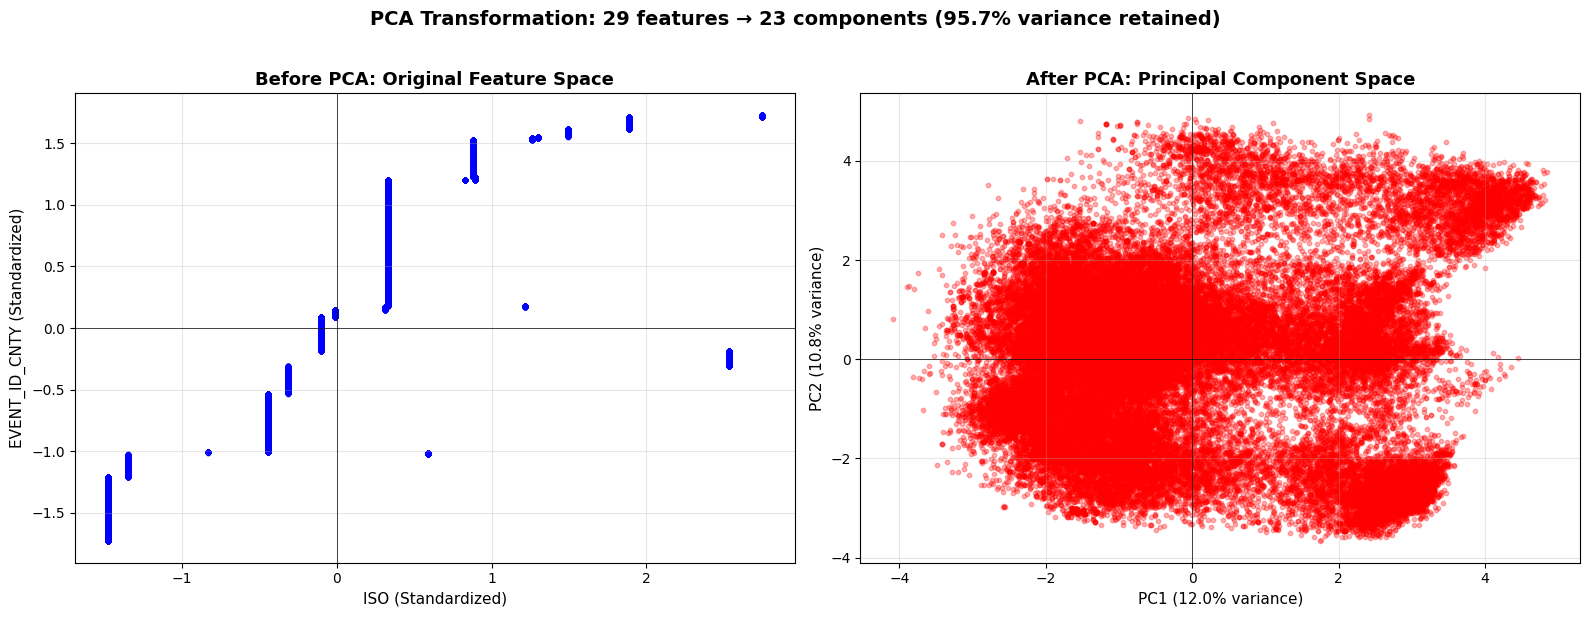

PCA TRANSFORMATION EXPLANATION

1. DATA POINTS PRESERVED: Both plots show 65535 data points.

2. AXES TRANSFORMATION:
   - Before: Original features (ISO vs EVENT_ID_CNTY)
   - After: Principal Components (PC1 vs PC2) — new axes of maximum variance

3. VARIANCE CONCENTRATION:
   - PC1 captures 12.0% of total variance
   - PC2 captures 10.8% of total variance
   - Together: 22.8%

4. DIMENSIONALITY REDUCTION:
   - Reduced from 29 to 23 dimensions
   - Retained 95.7% of total variance
   - 20.7% reduction in features

5. PCA SCALING: PC1 has the highest variance (largest spread), and data
   is centered at origin due to standardization.



In [44]:
# Step 8: Visualize Before and After PCA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Before PCA: First two original features
feat1_name = feature_names[0]
feat2_name = feature_names[1]

ax1.scatter(standardized_data[:, 0], standardized_data[:, 1],
            alpha=0.3, c='blue', s=10)
ax1.set_xlabel(f'{feat1_name} (Standardized)', fontsize=11)
ax1.set_ylabel(f'{feat2_name} (Standardized)', fontsize=11)
ax1.set_title('Before PCA: Original Feature Space', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='k', linewidth=0.5)
ax1.axvline(x=0, color='k', linewidth=0.5)

# After PCA: First two principal components
ax2.scatter(reduced_data[:, 0], reduced_data[:, 1],
            alpha=0.3, c='red', s=10)
ax2.set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}% variance)', fontsize=11)
ax2.set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}% variance)', fontsize=11)
ax2.set_title('After PCA: Principal Component Space', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linewidth=0.5)
ax2.axvline(x=0, color='k', linewidth=0.5)

plt.suptitle(f'PCA Transformation: {standardized_data.shape[1]} features → {num_components} components '
             f'({cumulative_variance[num_components-1]*100:.1f}% variance retained)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Explanation
print("PCA TRANSFORMATION EXPLANATION")
print(f"""
1. DATA POINTS PRESERVED: Both plots show {len(standardized_data)} data points.

2. AXES TRANSFORMATION:
   - Before: Original features ({feat1_name} vs {feat2_name})
   - After: Principal Components (PC1 vs PC2) — new axes of maximum variance

3. VARIANCE CONCENTRATION:
   - PC1 captures {explained_variance_ratio[0]*100:.1f}% of total variance
   - PC2 captures {explained_variance_ratio[1]*100:.1f}% of total variance
   - Together: {(explained_variance_ratio[0]+explained_variance_ratio[1])*100:.1f}%

4. DIMENSIONALITY REDUCTION:
   - Reduced from {standardized_data.shape[1]} to {num_components} dimensions
   - Retained {cumulative_variance[num_components-1]*100:.1f}% of total variance
   - {(1-num_components/standardized_data.shape[1])*100:.1f}% reduction in features

5. PCA SCALING: PC1 has the highest variance (largest spread), and data
   is centered at origin due to standardization.
""")